# Série histórica de um agravo (tuberculose)

**Pergunta que este notebook responde:** como o número de notificações de uma
doença evoluiu ao longo dos anos no Brasil?

**Fonte:** SINAN. O exemplo usa **tuberculose** (`TUBE`), mas basta trocar o
código para acompanhar qualquer outro agravo.
**Tempo estimado:** 6 a 10 minutos (baixa um arquivo por ano).

## Preparação

In [2]:
%pip install pysus nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

In [3]:
AGRAVO = "TUBE"              # TUBE, HANS, DENG, CHIK, ZIKA, LEPT, VIOL...
ANOS = [2020, 2021, 2022, 2023, 2024]

## Passo 1 — Conferir quais anos têm o agravo

In [4]:
from pysus import list_files

disponiveis = []
for ano in ANOS:
    catalogo = list_files(dataset="sinan", year=ano)
    agravos = {nome.split("\\")[-1][:4] for nome in catalogo["name"]}
    tem = AGRAVO in agravos
    print(f"  {ano}: {'✅' if tem else '❌'}")
    if tem:
        disponiveis.append(ano)

print(f"\nAnos que serão usados: {disponiveis}")

  2020: ✅


  2021: ✅


  2022: ✅


  2023: ✅


  2024: ✅

Anos que serão usados: [2020, 2021, 2022, 2023, 2024]


## Passo 2 — Contar as notificações de cada ano

Para não carregar milhões de linhas na memória, usamos a técnica de ler **apenas
as colunas necessárias** de cada arquivo. Aqui basta uma: a unidade federativa
de notificação.

In [5]:
import pandas as pd
from pysus import sinan

contagens = {}
por_uf_ano = {}

for ano in disponiveis:
    caminhos = sinan(disease=AGRAVO, year=ano, as_dataframe=False)
    dados = pd.read_parquet(caminhos[0], columns=["SG_UF_NOT"])
    contagens[ano] = len(dados)
    por_uf_ano[ano] = dados["SG_UF_NOT"].astype(str).value_counts()
    print(f"  {ano}: {len(dados):>9,} notificações")

serie = pd.Series(contagens).sort_index()

  2020:    85,962 notificações


  2021:    91,310 notificações


  2022:   103,330 notificações


  2023:   109,854 notificações


  2024:   112,988 notificações


## Passo 3 — A curva dos anos

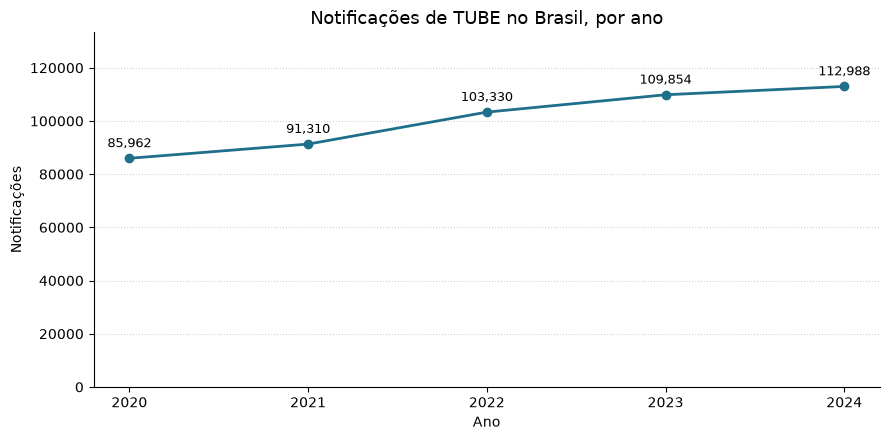

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(serie.index.astype(str), serie.values, marker="o",
        linewidth=2, color="#1f6f8b")

for x, y in zip(serie.index.astype(str), serie.values):
    ax.annotate(f"{y:,}", (x, y), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=9)

ax.set_title(f"Notificações de {AGRAVO} no Brasil, por ano", fontsize=13)
ax.set_ylabel("Notificações")
ax.set_xlabel("Ano")
ax.set_ylim(0, serie.max() * 1.18)
ax.grid(axis="y", linestyle=":", alpha=.6)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Passo 4 — Variação de um ano para o outro

In [7]:
variacao = serie.pct_change().mul(100).round(1)

tabela = pd.DataFrame({
    "Notificações": serie,
    "Variação (%)": variacao,
}).reset_index(names="Ano")
tabela

,Ano,Notificações,Variação (%)
0,2020,85962,NaN
1,2021,91310,6.2
2,2022,103330,13.2
3,2023,109854,6.3
4,2024,112988,2.9


## Passo 5 — Comparando estados ao longo do tempo

In [8]:
UFS = {
    "11": "RO", "12": "AC", "13": "AM", "14": "RR", "15": "PA", "16": "AP", "17": "TO",
    "21": "MA", "22": "PI", "23": "CE", "24": "RN", "25": "PB", "26": "PE", "27": "AL",
    "28": "SE", "29": "BA", "31": "MG", "32": "ES", "33": "RJ", "35": "SP",
    "41": "PR", "42": "SC", "43": "RS", "50": "MS", "51": "MT", "52": "GO", "53": "DF",
}

comparativo = pd.DataFrame(por_uf_ano).fillna(0).astype(int)
comparativo.index = comparativo.index.map(UFS)
comparativo = comparativo.dropna().sort_values(disponiveis[-1], ascending=False)

comparativo.head(10)

,2020,2021,2022,2023,2024
SG_UF_NOT,,,,,
SP,19541,20030,22984,24955,25812
RJ,13670,15087,16103,16950,17207
RS,6026,6289,6930,7386,7519
PE,5547,6068,7085,7440,7424
PA,4905,5270,5925,6117,6789
BA,4676,5059,5514,5535,5714
AM,3514,3946,4601,4938,5481
MG,3945,4005,4732,5164,5389
CE,3845,4124,4768,4763,4703


## Sobre a leitura destes números

- São **notificações**, não casos confirmados nem prevalência.
- Quedas bruscas em 2020 e 2021 costumam refletir a **subnotificação durante a
  pandemia**, não uma redução real da doença.
- Para comparar estados de tamanhos diferentes, é preciso calcular a
  **incidência por 100 mil habitantes**, usando a população do IBGE.

## Como adaptar

- **Outra doença:** troque `AGRAVO`. O notebook
  `_comece-aqui/02` lista todos os códigos disponíveis.
- **Outros anos:** mude a lista `ANOS`.
- **Recorte por estado:** filtre `SG_UF_NOT` pelo código do seu estado.

---
*Notebook do projeto [PySusNoCode](https://github.com/cartaproale/PySusNoCode) —
um produto [Kraemer Academy](https://kraemeracademy.net).
Validado com dados reais do DATASUS.*